# Retail sales report (demo)

A reproducible analysis of a real, public retail transaction log: raw export, row-by-row reconciled cleaning, three business
questions. Data: *Online Retail II*, UCI Machine Learning Repository (Chen, D., 2012, https://doi.org/10.24432/C5CG6D), CC BY 4.0.
This is a **demo analysis on public data**; the analysis plan (`ANALYSIS_PLAN.md`) was written before any number was computed.

Every number in this notebook is rendered from `results/*.json` by the code cells; none is typed into the text.
Years: **Year A** = Dec 2009 - Nov 2010, **Year B** = Dec 2010 - Nov 2011. December 2011 is partial and never compared.

**Definitions.** GPS = gross product sales (sum of quantity x price over product sale lines). CPV = cancelled product value
(absolute value of product cancellation lines). **NPR = GPS - CPV**, each line dated on its own invoice date.

## 1. Setup

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

from retail_report import report_data as rd

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists())
FIG = ROOT / "reports" / "figures"

# Set to True to recompute results/*.json from the ledger (needs $RETAIL_DATA_DIR, see "How to reproduce").
REBUILD = False
if REBUILD:
    from retail_report.build_results import main as build_results
    build_results()

R = rd.load_all()          # results/*.json
F = rd.facts(R)            # derived numbers, computed from the JSON values
A = rd.answers(R, F)       # one answer sentence per question


def show_table(rows, columns):
    """Compact table: list of row lists -> styled DataFrame without an index."""
    display(pd.DataFrame(rows, columns=columns).style.hide(axis="index"))


def show_figure(name, width=820):
    path = FIG / name
    if path.exists():
        display(Image(filename=str(path), width=width))
    else:
        display(Markdown(f"*Figure {name} not found: run `uv run python tools/build_figures.py`.*"))


display(Markdown(f"Results loaded from `results/*.json`. The raw data has {F['raw_rows']:,} rows."))

Results loaded from `results/*.json`. The raw data has 1,067,371 rows.

## 2. From raw rows to a reconciled ledger

Each raw row receives exactly one *disposition* (duplicates, accounting adjustments, cancellations, stock movements,
zero-price rows, non-product sales such as postage, and product sales), applied in a fixed order. Two identities must hold and are
asserted in code: row counts sum to the raw total, and the value of the dispositions sums to the raw value to the milli-pound.

In [2]:
rows = [[r["disposition"], f"{r['rows']:,}", rd.gbp_full(r["value_gbp"]), f"{r['no_id_rows']:,}", rd.gbp_full(r["no_id_value_gbp"])]
        for r in rd.ledger_rows(R) + [rd.ledger_total(R)]]
show_table(rows, ["Disposition", "Rows", "Value", "Rows without customer ID", "Value without customer ID"])
ident = R["rec"]["identities"]
display(Markdown(f"Row counts sum to the raw total: **{ident['row_count_sums_to_raw']}**. "
                 f"Values sum to the raw value exactly: **{ident['value_sums_to_raw_exactly']}**. "
                 f"Rows left unclassified: **{R['rec']['dispositions']['unclassified']['rows']}**. "
                 f"Rows without a customer ID: **{rd.pct(F['no_id_share_of_raw_rows'])}** of all raw rows."))

Disposition,Rows,Value,Rows without customer ID,Value without customer ID
dup_cross_sheet,"22,523","£377,488","7,720","£72,865"
dup_exact,"11,812","£54,228",136,£551
adjustment,6,"−£147,614",6,"−£147,614"
cancel_product,"17,915","−£716,463",328,"−£6,473"
cancel_non_product,"1,189","−£745,588",386,"−£370,765"
stock_movement,"3,393",£0,"3,393",£0
zero_price,"2,621",£0,"2,551",£0
sale_non_product,"4,555","£821,337","1,726","£515,115"
sale_product,"1,003,357","£19,643,862","226,761","£2,575,279"
unclassified,0,£0,0,£0


Row counts sum to the raw total: **True**. Values sum to the raw value exactly: **True**. Rows left unclassified: **0**. Rows without a customer ID: **22.8%** of all raw rows.

## 3. Q1. Where did revenue growth come from between Year A and Year B?

**Answer**

In [3]:
display(Markdown(A["q1"]))
display(Markdown(A["q1_country"]))

Net product revenue (NPR) rose 1.9% from Year A to Year B (£9.16M to £9.33M), but identified customers' NPR fell 2.0%. Retained customers (2,708) spent £548k less (−7.7%); new customers added £1.40M, which offset the £1.02M lost with customers who did not return; sales without a customer ID added £341k.

The UK was flat (−£4.5k, −0.06%). Australia (+£108k) and France (+£64.3k) grew; EIRE fell (−£91.5k).

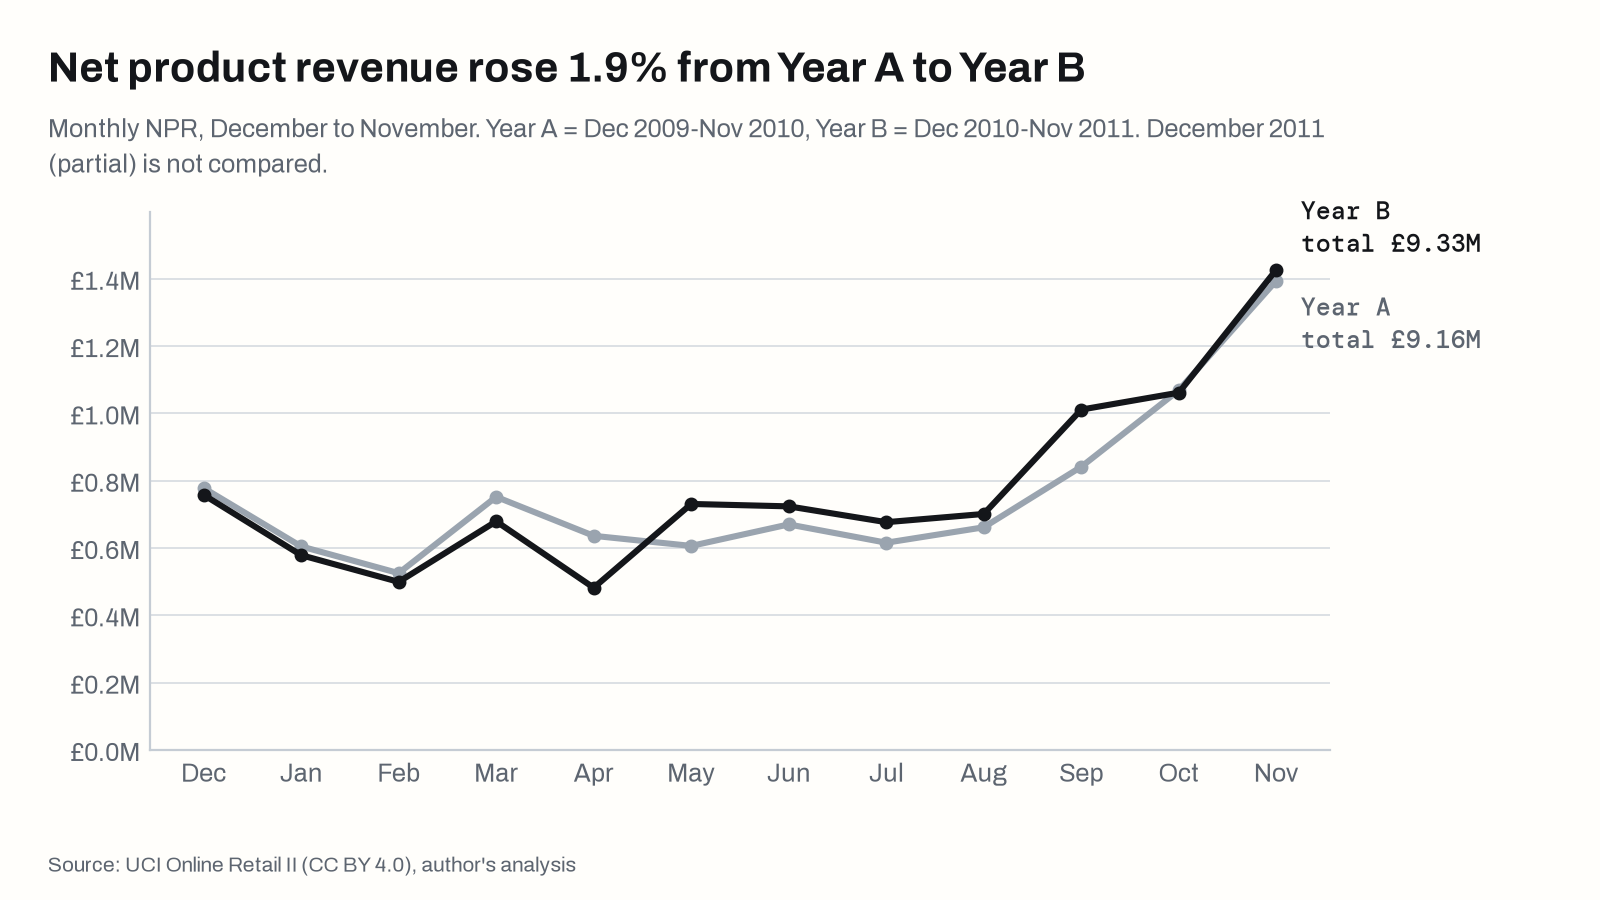

In [4]:
show_figure("01_monthly_npr.png")

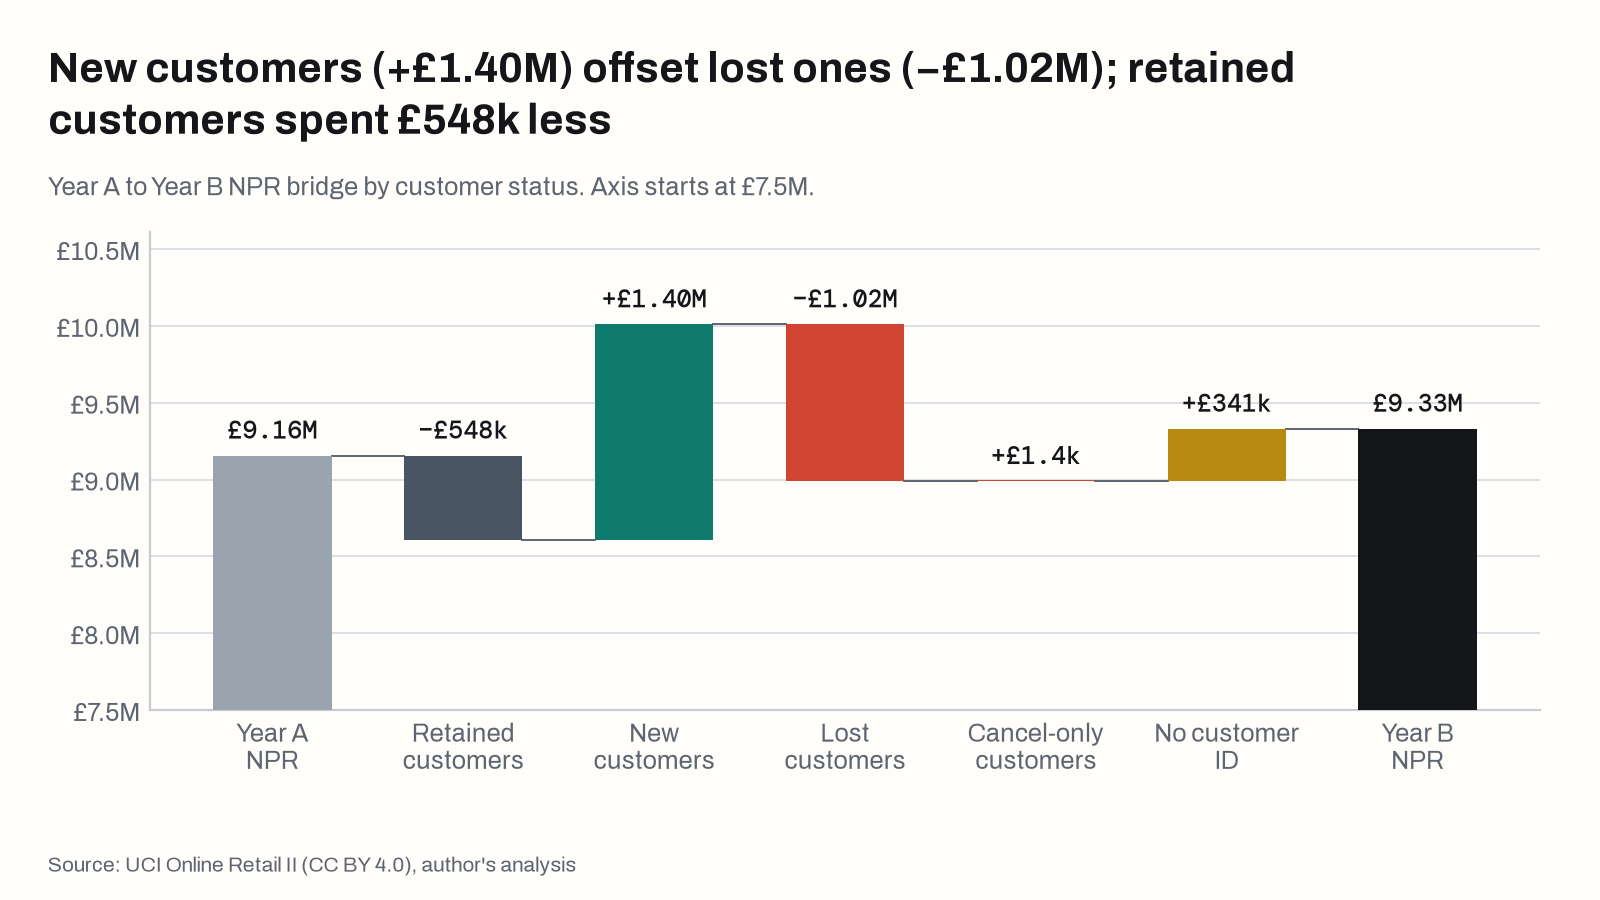

In [5]:
show_figure("02_npr_bridge.png")

The change in NPR is decomposed additively by customer status; the decomposition sums to the total change exactly.

In [6]:
st = R["q1"]["by_customer_status"]["entries"]
names = {"retained": "Retained (bought in A and B)", "new_in_b": "New (bought in B only)", "lost": "Lost (bought in A only)",
         "cancel_only_no_sale_in_a_or_b": "Cancel-only (no sale in A or B)", "no_customer_id": "No customer ID"}
rows = [[names[k], f"{v['customers']:,}" if v["customers"] else "", rd.gbp_full(v["npr_a_gbp"]), rd.gbp_full(v["npr_b_gbp"]), rd.gbp_full(v["delta_gbp"], True)]
        for k, v in st.items()]
rows.append(["Total", "", rd.gbp_full(R["q1"]["npr_a_gbp"]), rd.gbp_full(R["q1"]["npr_b_gbp"]), rd.gbp_full(R["q1"]["delta_npr_gbp"], True)])
show_table(rows, ["Customer status", "Customers", "Year A NPR", "Year B NPR", "Change"])

Customer status,Customers,Year A NPR,Year B NPR,Change
Retained (bought in A and B),"2,708","£7,077,548","£6,529,204","−£548,345"
New (bought in B only),"1,585",−£408,"£1,402,041","+£1,402,449"
Lost (bought in A only),"1,531","£1,017,381","−£3,919","−£1,021,299"
Cancel-only (no sale in A or B),23,"−£1,405",−£1,"+£1,404"
No customer ID,,"£1,062,965","£1,403,594","+£340,629"
Total,,"£9,156,081","£9,330,919","+£174,838"


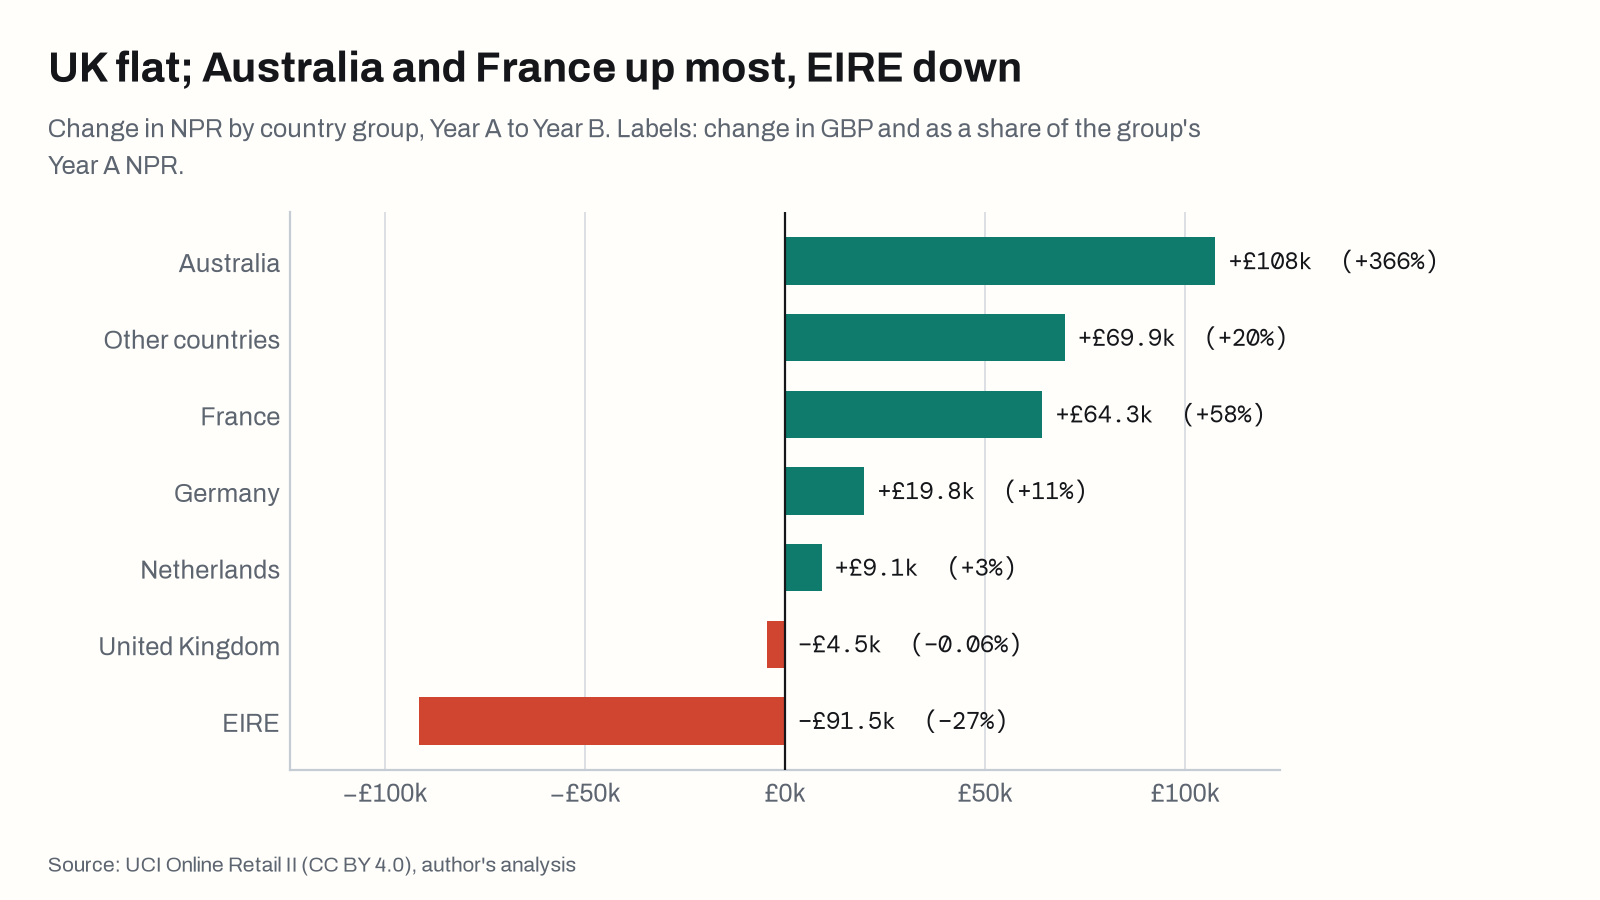

In [7]:
show_figure("03_country_delta.png")

In [8]:
ce = R["q1"]["by_country_group"]["entries"]
rows = [[k, rd.gbp_full(v["npr_a_gbp"]), rd.gbp_full(v["npr_b_gbp"]), rd.gbp_full(v["delta_gbp"], True),
         rd.pct(F["country_pct"][k], 1, True)] for k, v in ce.items()]
show_table(rows, ["Country group", "Year A NPR", "Year B NPR", "Change", "Change %"])
bp = R["q1"]["by_product"]
display(Markdown(f"By product ({bp['products']:,} products), the ten largest movers account for only **{rd.pct(bp['top10_share_of_gross_movement'])}** "
                 f"of the total gross movement: the change is broad, not a handful of products."))

Country group,Year A NPR,Year B NPR,Change,Change %
United Kingdom,"£7,887,516","£7,883,044","−£4,472",−0.1%
Netherlands,"£262,616","£271,752","+£9,136",+3.5%
EIRE,"£343,737","£252,257","−£91,480",−26.6%
Germany,"£173,954","£193,775","+£19,821",+11.4%
France,"£111,355","£175,685","+£64,331",+57.8%
Australia,"£29,360","£136,922","+£107,563",+366.4%
Other,"£347,545","£417,483","+£69,939",+20.1%


By product (4,738 products), the ten largest movers account for only **6.5%** of the total gross movement: the change is broad, not a handful of products.

In [9]:
bp = R["q1"]["by_product"]
rows = [[p["description"].strip(), p["stock_code"], rd.gbp_full(p["npr_a_gbp"]), rd.gbp_full(p["npr_b_gbp"]), rd.gbp_full(p["delta_gbp"], True)] for p in bp["top10"]]
show_table(rows, ["Product", "Code", "Year A NPR", "Year B NPR", "Change"])

Product,Code,Year A NPR,Year B NPR,Change
RABBIT NIGHT LIGHT,23084,£0,"£57,058","+£57,058"
WHITE HANGING HEART T-LIGHT HOLDER,85123A,"£151,991","£97,408","−£54,582"
PARTY BUNTING,47566,"£48,836","£97,325","+£48,490"
SPOTTY BUNTING,23298,£0,"£41,901","+£41,901"
PICNIC BASKET WICKER SMALL,22502,"£9,420","£51,024","+£41,603"
JUMBO BAG VINTAGE DOILY,23203,£0,"£39,604","+£39,604"
SET OF 3 CAKE TINS PANTRY DESIGN,22720,£0,"£36,330","+£36,330"
DOORMAT KEEP CALM AND COME IN,23284,£0,"£34,991","+£34,991"
JAM MAKING SET WITH JARS,22960,"£1,298","£34,827","+£33,529"
SET OF 3 REGENCY CAKE TINS,23245,£0,"£29,066","+£29,066"


**What this does not say**

- It does not say why customers left or joined: there is no marketing, pricing or survey data.
- Customers with no ID are not random and could be retail or wholesale buyers; the data cannot say who they are.
- Customer history starts in December 2009, so a customer counted as *new* may simply be new to this data.
- There is no cost data: nothing here is about margin or profit.

## 4. Q2. How dependent is revenue on a few customers, and do new customers come back?

**Answer**

In [10]:
display(Markdown(A["q2"]))

Revenue is concentrated: the top 1% of identified customers (43 of 4,321) account for 30% of identified Year B NPR, the top 10 customers for 17%. Pooled over cohorts 2010-03 to 2011-08, 38.8% of new customers place a second order within 90 days (n = 3,530).

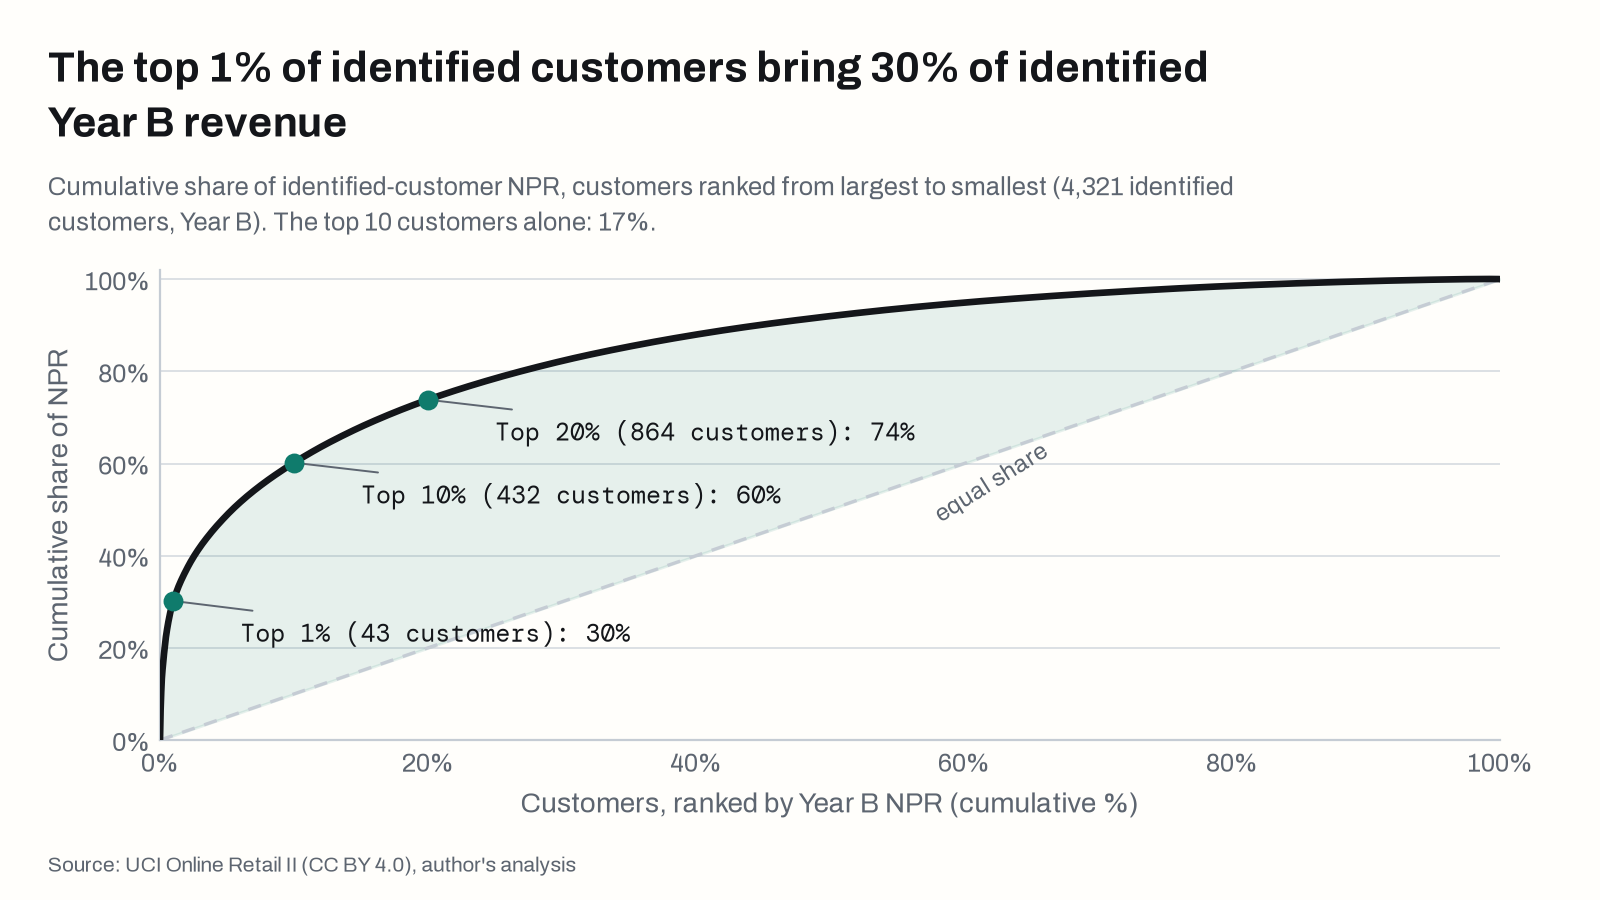

In [11]:
show_figure("04_concentration.png")

In [12]:
c = R["q2"]["concentration_year_b"]
rows = [[lab, f"{c[k]['customers']:,}", rd.gbp_full(c[k]["npr_gbp"]), rd.pct(c[k]["share_of_identified_npr"]), rd.pct(c[k]["share_of_total_npr"])]
        for k, lab in (("top_1pct", "Top 1%"), ("top_10pct", "Top 10%"), ("top_20pct", "Top 20%"), ("top_10_customers", "Top 10 customers"))]
show_table(rows, ["Group", "Customers", "Year B NPR", "Share of identified NPR", "Share of total NPR"])
display(Markdown(f"{c['identified_customers']:,} identified customers; {c['negative_npr_customers']} have negative NPR (kept in the ranking). "
                 f"No-ID sales are {rd.gbp_short(c['no_id_npr_gbp'])} of Year B NPR and are outside this ranking."))

Group,Customers,Year B NPR,Share of identified NPR,Share of total NPR
Top 1%,43,"£2,391,928",30.2%,25.6%
Top 10%,432,"£4,770,603",60.2%,51.1%
Top 20%,864,"£5,854,146",73.9%,62.7%
Top 10 customers,10,"£1,323,978",16.7%,14.2%


4,321 identified customers; 30 have negative NPR (kept in the ranking). No-ID sales are £1.40M of Year B NPR and are outside this ranking.

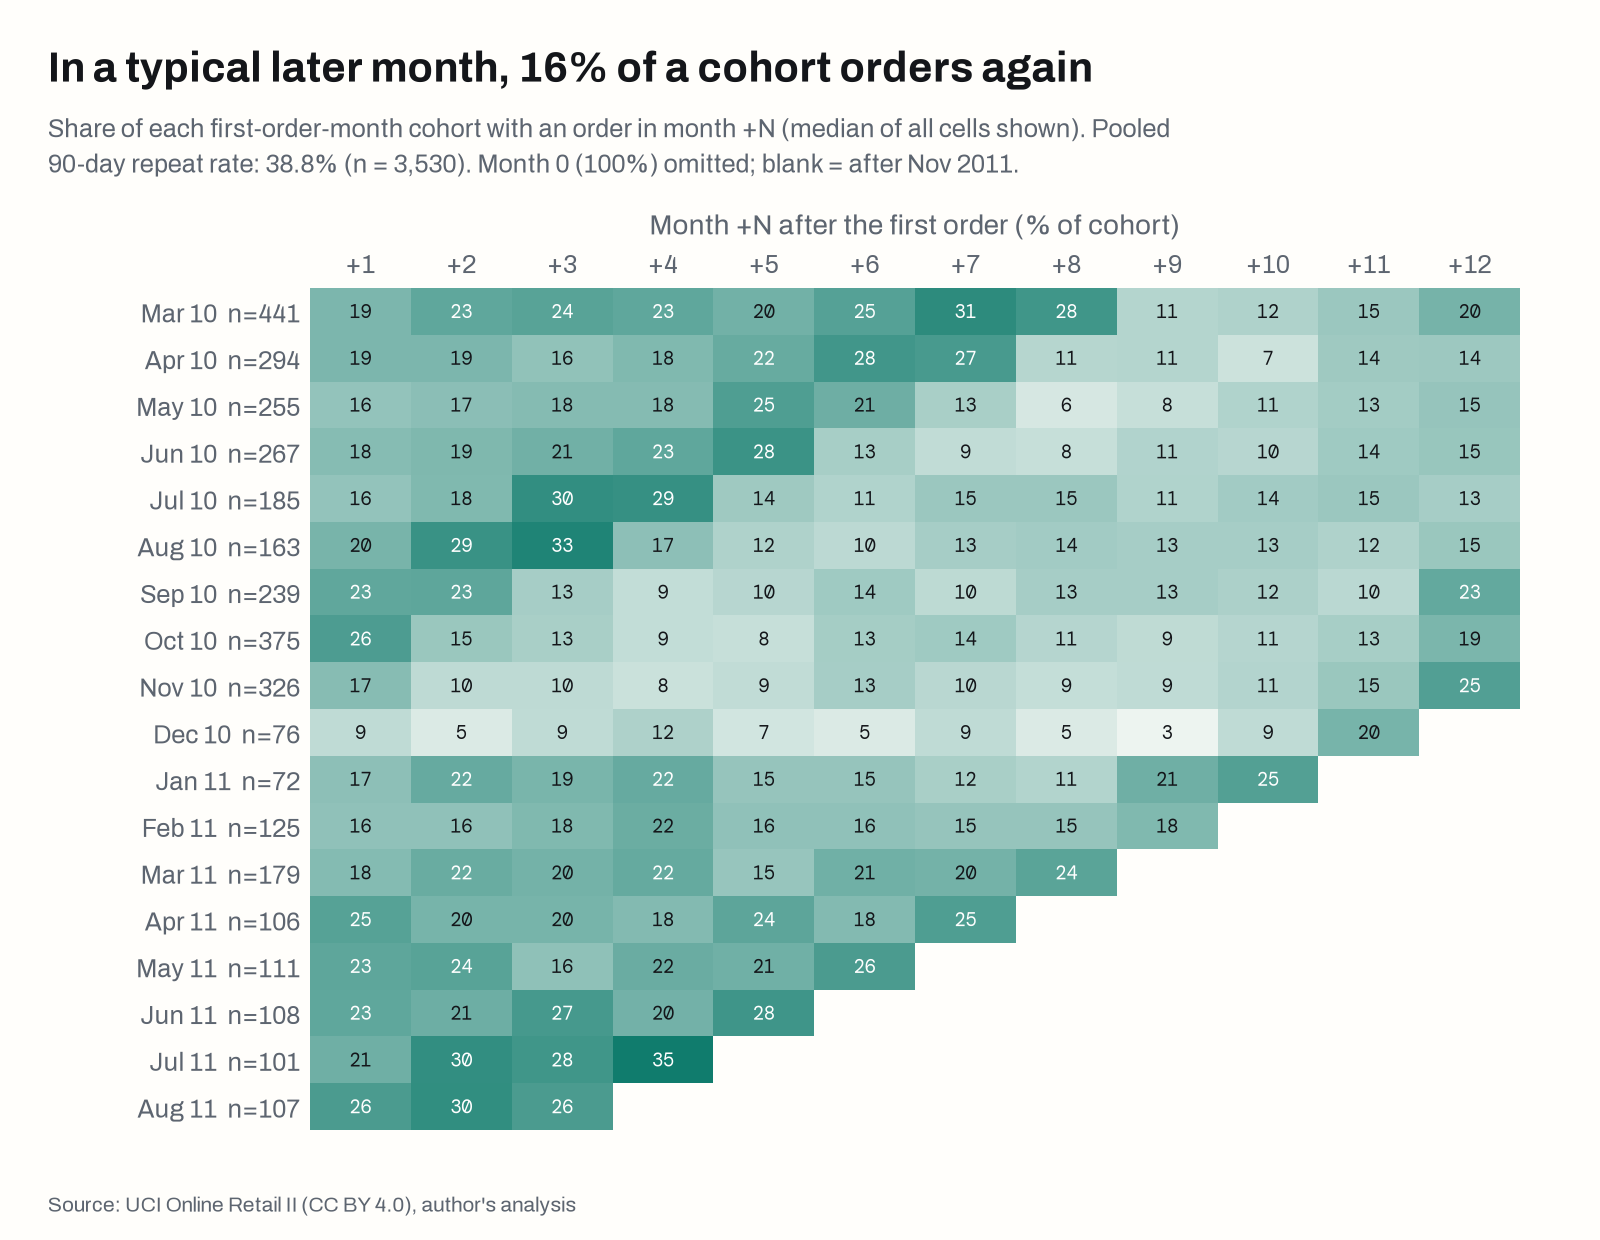

In [13]:
show_figure("05_cohort_retention.png", width=760)

In [14]:
rp = R["q2"]["repeat_purchase"]
rows = [[m, f"{v['customers']:,}", f"{v['repeaters']:,}", rd.pct(v["rate"])] for m, v in rp["cohorts"].items() if v["included"]]
p = rp["pooled"]
rows.append(["Pooled", f"{p['customers']:,}", f"{p['repeaters']:,}", rd.pct(p["rate"])])
show_table(rows, ["First-order month", "New customers", "Repeat within 90 days", "Repeat rate"])
pre = rp["before_2010_03_shown_separately"]
display(Markdown(f"Cohorts before 2010-03 ({pre['customers']:,} customers, {rd.pct(pre['pooled_rate'])} repeat) are left out of the pooled rate because "
                 f"'new' is left-censored there; cohorts after {F['repeat_last']} do not yet have a full 90-day window."))

First-order month,New customers,Repeat within 90 days,Repeat rate
2010-03,441,182,41.3%
2010-04,294,112,38.1%
2010-05,255,86,33.7%
2010-06,267,92,34.5%
2010-07,185,80,43.2%
2010-08,163,81,49.7%
2010-09,239,103,43.1%
2010-10,375,144,38.4%
2010-11,326,98,30.1%
2010-12,76,12,15.8%


Cohorts before 2010-03 (1,694 customers, 55.2% repeat) are left out of the pooled rate because 'new' is left-censored there; cohorts after 2011-08 do not yet have a full 90-day window.

**What this does not say**

- Cohorts before March 2010 are excluded from the repeat rate because their *newness* is left-censored.
- The repeat rate says how many customers returned, not how much they spent when they did.
- It covers one retailer, so it is not a statement about the market.

## 5. Q3. How much revenue is lost to cancellations, and where is it concentrated?

**Answer**

In [15]:
display(Markdown(A["q3"]))

Cancelled product value (CPV) as a share of gross product sales (GPS) went from 2.6% in Year A to 3.1% in Year B. Without the 10 largest single cancellation lines it goes from 2.5% to 2.1%: the rise is driven by a few very large lines. 93% of cancelled value can be traced to an earlier order.

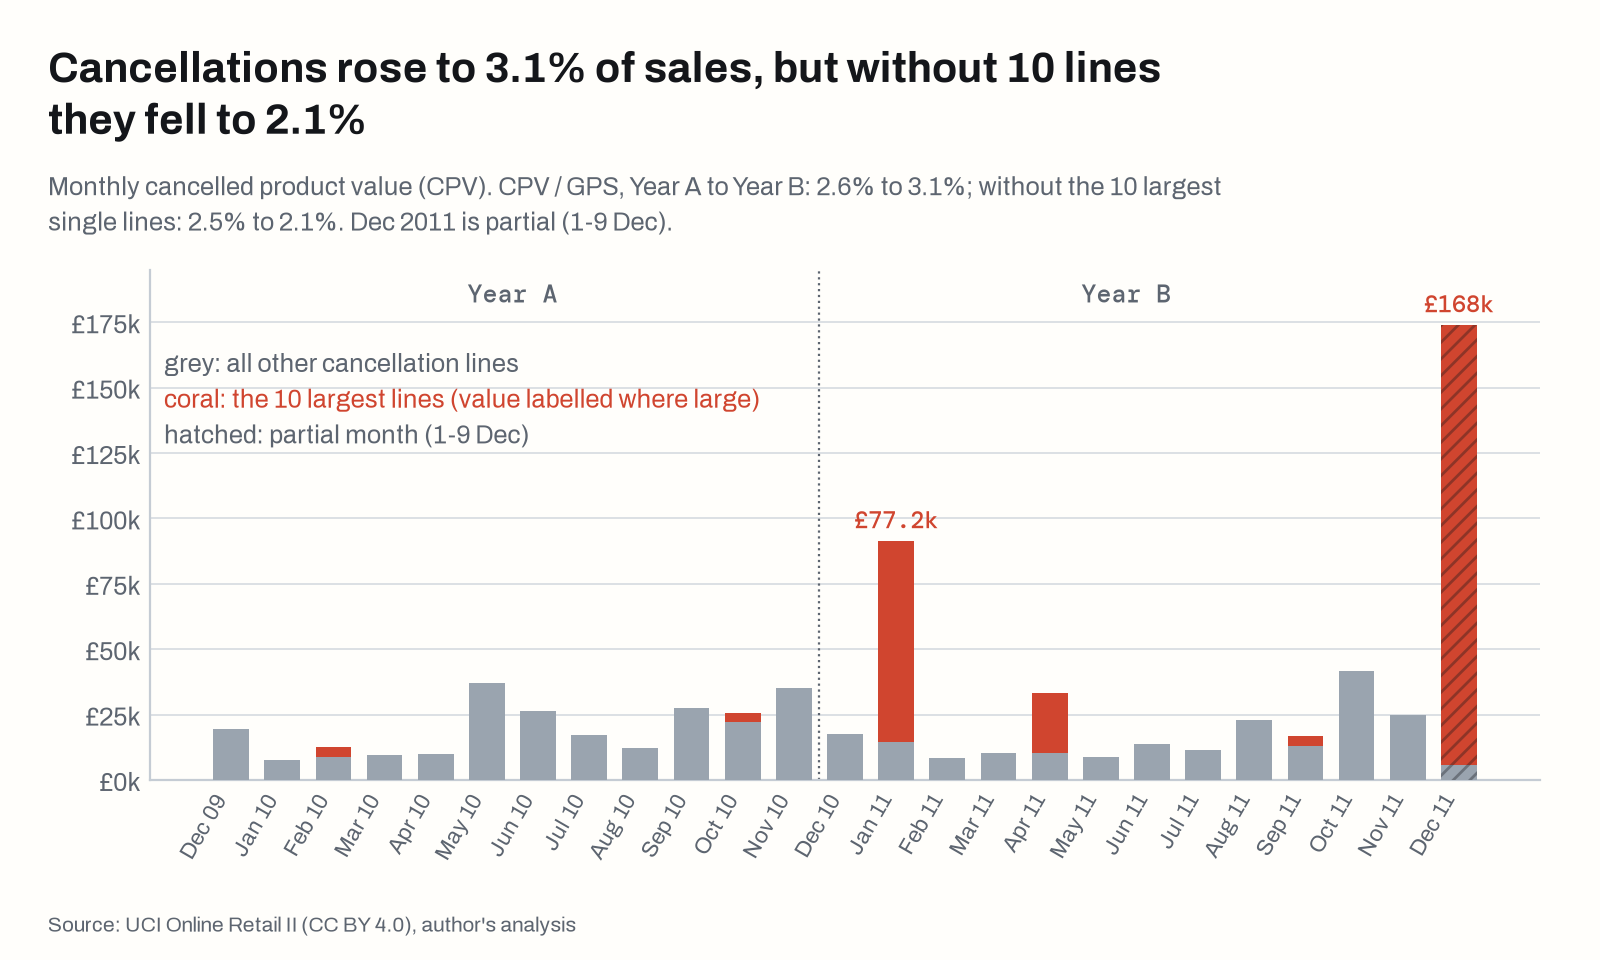

In [16]:
show_figure("06_cancellations.png")

In [17]:
rows = []
for per, lab in (("year_a", "Year A"), ("year_b", "Year B")):
    for var, vl in (("with_top10_lines", "all lines"), ("without_top10_lines", "without the 10 largest lines")):
        h = R["q3"]["headlines"][per][var]
        rows.append([f"{lab}, {vl}", rd.gbp_full(h["gps_gbp"]), rd.gbp_full(h["cpv_gbp"]), rd.pct(h["cpv_over_gps"]),
                     rd.pct(h["top20_products_share_of_cpv"], 0), rd.pct(h["top20_customers_share_of_cpv"], 0)])
show_table(rows, ["Period", "GPS", "CPV", "CPV / GPS", "Top-20 products' share of CPV", "Top-20 customers' share of CPV"])

Period,GPS,CPV,CPV / GPS,Top-20 products' share of CPV,Top-20 customers' share of CPV
"Year A, all lines","£9,396,642","£240,561",2.6%,25%,41%
"Year A, without the 10 largest lines","£9,396,642","£233,763",2.5%,24%,40%
"Year B, all lines","£9,632,728","£301,810",3.1%,47%,59%
"Year B, without the 10 largest lines","£9,632,728","£197,802",2.1%,23%,39%


In [18]:
t = R["q3"]["top10_cancellation_lines"]
rows = [[ln["date"][:10], ln["invoice"], ln["description"].strip(), f"{ln['quantity']:,}", rd.gbp_full(ln["value_gbp"]), "yes" if ln["traceable"] else "no"]
        for ln in t["lines"]]
show_table(rows, ["Date", "Invoice", "Product", "Quantity", "Value", "Traceable"])
display(Markdown(f"The ten largest single cancellation lines total **{rd.gbp_full(t['total_value_gbp'])}**, "
                 f"{rd.pct(t['share_of_whole_period_cpv'])} of all cancelled value in the period. "
                 f"{F['top10_lines_in_b']} of them fall in Year B."))

Date,Invoice,Product,Quantity,Value,Traceable
2011-12-09,C581484,"PAPER CRAFT , LITTLE BIRDIE","-80,995","£168,470",yes
2011-01-18,C541433,MEDIUM CERAMIC TOP STORAGE JAR,"-74,215","£77,184",yes
2011-04-18,C550456,FAIRY CAKE FLANNEL ASSORTED COLOUR,"-3,114","£6,539",yes
2011-04-18,C550456,WHITE HANGING HEART T-LIGHT HOLDER,"-1,930","£4,922",yes
2011-04-18,C550456,DOORMAT FAIRY CAKE,-670,"£4,522",yes
2011-09-21,C567527,PANTRY CHOPPING BOARD,-756,"£3,825",yes
2011-04-18,C550456,GIN + TONIC DIET METAL SIGN,"-2,000","£3,700",yes
2010-02-17,C498151,SMALL FAIRY CAKE FRIDGE MAGNETS,"-2,504","£3,631",yes
2011-04-18,C550456,TEA TIME PARTY BUNTING,"-1,300","£3,315",no
2010-10-28,C529352,COLOUR GLASS. STAR T-LIGHT HOLDER,"-1,152","£3,168",yes


The ten largest single cancellation lines total **£279,276**, 39.0% of all cancelled value in the period. 7 of them fall in Year B.

In [19]:
cr = R["q3"]["cancellation_rate"]
rows = [[x["description"].strip(), x["stock_code"], f"{x['sold_units']:,}", f"{x['cancelled_units']:,}", rd.pct(x["rate"], 0)]
        for x in cr["with_top10_lines"]["top20"][:10]]
show_table(rows, ["Product (top 10 by cancellation rate)", "Code", "Sold units", "Cancelled units", "Rate"])
tr = R["q3"]["headlines"]["whole_period"]["with_top10_lines"]["traceability"]
display(Markdown(f"Among {cr['with_top10_lines']['eligible_products']:,} products with enough sales, pooled cancelled units are "
                 f"{rd.pct(cr['with_top10_lines']['pooled_rate_eligible_products'])} of sold units "
                 f"({rd.pct(cr['without_top10_lines']['pooled_rate_eligible_products'])} without the 10 largest lines). "
                 f"Traceability: **{rd.pct(tr['traceable']['share_of_value'])}** of cancelled value ({rd.pct(tr['traceable']['share_of_lines'])} of lines) "
                 f"has an earlier order of the same customer, product and price; {rd.pct(tr['no_customer_id']['share_of_value'])} has no customer ID."))

Product (top 10 by cancellation rate),Code,Sold units,Cancelled units,Rate
MEDIUM CERAMIC TOP STORAGE JAR,23166,"78,033","74,494",95%
PANTRY CHOPPING BOARD,23113,"1,154",946,82%
IVORY CHANDELIER T-LIGHT HOLDER,23055,657,432,66%
WILLOW BRANCH LIGHTS.,79341,725,448,62%
FLOWERS CHANDELIER T-LIGHT HOLDER,23056,963,579,60%
BEADED CHANDELIER T-LIGHT HOLDER,23057,773,433,56%
WHITE BIRD GARDEN DESIGN MUG,85160A,"8,824","4,320",49%
BLUE BREAKFAST CUP AND SAUCER,37444B,"2,010",984,49%
PASTEL PINK PHOTO ALBUM,16202A,662,324,49%
POP ART PEN CASE & PENS,16047,"10,612","5,184",49%


Among 2,523 products with enough sales, pooled cancelled units are 3.4% of sold units (2.6% without the 10 largest lines). Traceability: **92.9%** of cancelled value (85.7% of lines) has an earlier order of the same customer, product and price; 0.9% has no customer ID.

**What this does not say**

- *Traceable* means an earlier order of that customer, product and price exists, not that the cancelled quantity is fully covered.
- The data gives no cancellation reasons.
- Removing the 10 largest lines is a sensitivity check, not a claim that they are errors.

## 6. Assumptions and limitations

In [20]:
display(Markdown("\n".join(f"- {t}" for t in rd.LIMITATIONS)))

- The data covers December 2009 to December 2011 (2011-12 is partial, 1-9 Dec) and one UK-based online retailer: it is not a market.
- There is no cost column, so no margin or profit claim is made anywhere in this report.
- Missing customer IDs are not random; the data cannot say who those buyers are.
- Customer history is left-censored: it starts in December 2009, so 'new' means first seen in this data.
- 'Traceable' cancellations have an earlier order of the same customer, product and price; quantity is not compared, so traceable is not the same as fully covered.
- Year A and Year B are two 12-month windows; nothing here says what happens in a third year.

Other choices are recorded, with dates and reasons, in the *Amendments* section of `ANALYSIS_PLAN.md`
(money held in milli-pounds, product-code normalisation, rounding of the top-share group sizes, cohort windows, traceability rule).

In [21]:
ic = R["indep"]
display(Markdown(f"**Independent check.** A second implementation, written from the raw CSV and the plan only, compared {ic['rows_compared']:,} rows "
                 f"({ic['row_disposition_mismatches']} disposition mismatches) and {ic['numbers_compared']} headline numbers "
                 f"({len(ic['number_mismatches'])} mismatches)."))

**Independent check.** A second implementation, written from the raw CSV and the plan only, compared 1,067,371 rows (0 disposition mismatches) and 118 headline numbers (0 mismatches).

## 7. How to reproduce

1. Download `online_retail_II.xlsx` from the UCI page cited above (the raw file is not redistributed here).
2. `uv run python tools/export_raw_csv.py` checks the file's SHA-256 and exports the two sheets to CSV.
3. `uv run python -m retail_report.build_results` builds the ledger and writes `results/reconciliation.json`, `q1.json`, `q2.json`, `q3.json`.
4. `uv run python tools/build_reports.py` rebuilds the figures, the Excel workbook, the summary slide and this notebook.
5. `uv run pytest -q` runs the tests (ledger rules, reconciliation identities, decompositions, workbook and figures).

Set `REBUILD = True` in the setup cell to recompute the results from inside the notebook.

*Source: UCI Online Retail II (CC BY 4.0), author's analysis. Demo analysis on public data.*